# EgoRecall — 02: Frame Extraction

**What this notebook does:**  
Reads clip videos from GCS and extracts three types of frames needed by downstream notebooks.

| Output | Purpose | Destination |
|--------|---------|-------------|
| Detection frames + YOLO labels | Train YOLOv8 / DETR | `frames/detection/` + `labels/yolo/` |
| Visual crop images | Retrieval query embeddings | `frames/retrieval/visual_crops/` |
| Index frames (1 FPS) | FAISS index building | `frames/retrieval/index_frames/` |

**Key decisions from EDA:**
- Use `frame_number` (clip-relative, 5 FPS) — annotations were drawn on clip frames
- 1 FPS sampling for index frames (~1.4M total vs ~7M at 5 FPS)
- Single class label (`0`) for YOLO — detection is object-agnostic; retrieval handles identity
- Process clip-by-clip: download → extract → upload → delete to stay within Colab storage

**Expected scale:**
- Detection frames : ~266,771
- Visual crops     : ~18,114
- Index frames     : ~1.4M (4,690 clips × ~300 frames at 1 FPS)


## 0 · Imports & Config

In [ ]:
!pip install google-cloud-storage opencv-python-headless tqdm --quiet

In [ ]:
import json
import os
import shutil
import tempfile
import time
from pathlib import Path
from collections import defaultdict

import cv2
import numpy as np
import pandas as pd
from google.cloud import storage
from tqdm.notebook import tqdm

# ── GCS config ─────────────────────────────────────────────────────────────
BUCKET_NAME   = "egorecall-data"
GCS_VIDEO_DIR = ""                          # clips are at bucket root
GCS_OUT = {
    "detection_frames" : "frames/detection",
    "visual_crops"     : "frames/retrieval/visual_crops",
    "index_frames"     : "frames/retrieval/index_frames",
    "yolo_labels"      : "labels/yolo",
    "manifest"         : "processed/extraction_manifest.parquet",
}

# ── Local temp dir (Colab has ~100GB; we process one clip at a time) ───────
TMP_DIR = Path("/tmp/egorecall")
TMP_DIR.mkdir(exist_ok=True)

# ── Extraction settings ────────────────────────────────────────────────────
INDEX_FPS       = 1        # frames per second to sample for FAISS index
CLIP_FPS        = 5        # all clips are 5 FPS (confirmed in EDA)
INDEX_STRIDE    = CLIP_FPS // INDEX_FPS   # = 5: take every 5th frame
JPEG_QUALITY    = 90
YOLO_CLASS_ID   = 0        # single class — object-agnostic detection

# ── Checkpoint file — resume if Colab disconnects ─────────────────────────
CHECKPOINT_PATH = Path("extraction_checkpoint.json")

print("Config ready.")
print(f"  Index stride : every {INDEX_STRIDE} frames (= {INDEX_FPS} FPS)")
print(f"  YOLO class   : {YOLO_CLASS_ID} (object-agnostic)")

Config ready.
  Index stride : every 5 frames (= 1 FPS)
  YOLO class   : 0 (object-agnostic)


## 1 · Authentication & GCS Client

In [ ]:
# import subprocess
# subprocess.run(["gcloud", "auth", "revoke", "--all"], capture_output=True)

# !gcloud auth application-default revoke
# !gcloud auth application-default login

In [ ]:

# # Authenticate — use whichever method matches your GCP setup
from google.colab import auth
auth.authenticate_user()

gcs_client = storage.Client()
bucket     = gcs_client.bucket(BUCKET_NAME)
print(f"Connected to gs://{BUCKET_NAME}")

Connected to gs://egorecall-data


In [ ]:
# !gcloud auth application-default login

In [ ]:
# !gcloud auth list
# !gcloud projects get-iam-policy visual-memory-acv-project \
#   --flatten="bindings[].members" \
#   --filter="bindings.members:Khadijahlawal99@gmail.com" \
#   --format="table(bindings.role)"

In [ ]:
gcs_client = storage.Client()
bucket     = gcs_client.bucket(BUCKET_NAME)

In [ ]:
# Estimate storage needed
# avg_frame_size_kb = 50  # typical JPEG at 720x540, quality 90
# total_frames = 246206
# total_gb = (total_frames * avg_frame_size_kb) / (1024**2)
# print(f"Estimated storage: {total_gb:.1f} GB")

Estimated storage: 11.7 GB


In [ ]:
# # Sample 100 blobs and check actual sizes
# blobs = list(gcs_client.list_blobs(
#     "egorecall-data",
#     prefix="frames/detection/train/",
#     max_results=100
# ))
# sizes = [b.size for b in blobs]
# avg_kb = sum(sizes) / len(sizes) / 1024
# total_gb = (avg_kb * 246206) / (1024**2)
# print(f"Actual avg frame size : {avg_kb:.1f} KB")
# print(f"Estimated total       : {total_gb:.1f} GB")

Actual avg frame size : 80.4 KB
Estimated total       : 18.9 GB


## 2 · Load Annotations & Build Per-Clip Work Plan

We group all query-sets by `clip_uid` so we only download each clip once  
and extract all needed frames in a single pass.

In [ ]:
# ── Load the clean query-sets parquet from GCS ─────────────────────────────
!gsutil cp gs://{BUCKET_NAME}/processed/vq_query_sets.parquet /tmp/vq_query_sets.parquet
df = pd.read_parquet("/tmp/vq_query_sets.parquet")
print(f"Loaded {len(df):,} valid query-sets across {df['clip_uid'].nunique():,} clips")

Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
Copying gs://egorecall-data/processed/vq_query_sets.parquet...
/ [1 files][  2.1 MiB/  2.1 MiB]                                                
Operation completed over 1 objects/2.1 MiB.                                      
Loaded 18,114 valid query-sets across 4,690 clips


In [ ]:
# ── Load raw JSON to recover response track frame numbers ──────────────────
ANNO_DIR = Path("/tmp")
!gsutil cp gs://{BUCKET_NAME}/ego4d/v2/annotations/vq_train.json /tmp/vq_train.json
!gsutil cp gs://{BUCKET_NAME}/ego4d/v2/annotations/vq_val.json   /tmp/vq_val.json

with open("/tmp/vq_train.json") as f:
    train_raw = json.load(f)
with open("/tmp/vq_val.json") as f:
    val_raw = json.load(f)
print("Annotations loaded.")

Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
Copying gs://egorecall-data/ego4d/v2/annotations/vq_train.json...
- [1 files][ 92.5 MiB/ 92.5 MiB]                                                
Operation completed over 1 objects/92.5 MiB.                                     
Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
Copying gs://egorecall-data/ego4d/v2/annotations/vq_val.json...
/ [1 files][ 31.4 MiB/ 31.4 MiB]                                                
Operation completed over 1 objects/31.4 MiB.                                     
Annotations loaded.


In [ ]:
def build_video_workplan(train_raw, val_raw):
    """
    Keyed by video_uid. One download per video regardless of clip count.
    Uses video_frame_number for seeking in the 30 FPS source video.
    """
    plan = {}

    for split, raw in [("train", train_raw), ("val", val_raw)]:
        for video in raw["videos"]:
            vid = video["video_uid"]
            if vid not in plan:
                plan[vid] = {"split": split, "clips": {}}

            for clip in video["clips"]:
                cuid = clip["clip_uid"]

                # Safely get necessary time and frame values, defaulting to 0 if None
                # Use 'or 0' to handle cases where the key exists but its value is None
                clip_start_sec = clip.get("clip_start_sec") or 0
                clip_end_sec = clip.get("clip_end_sec") or 0
                video_end_sec = clip.get("video_end_sec") or 0
                video_end_frame = clip.get("video_end_frame") or 0
                video_start_frame = clip.get("video_start_frame") or 0

                # Calculate video_fps, handling potential division by zero
                video_fps = CLIP_FPS  # Default to a predefined safe value (e.g., 5 FPS from config)
                if video_end_sec > 0:
                    video_fps = round(video_end_frame / video_end_sec)

                # Ensure clip_duration is non-negative
                clip_duration = max(0, clip_end_sec - clip_start_sec)

                plan[vid]["clips"][cuid] = { # Fixed: Added missing bracket here
                    "clip_fps"          : clip["clip_fps"],
                    "clip_duration"     : clip_duration,
                    "video_start_frame" : video_start_frame,
                    "video_end_frame"   : video_end_frame,
                    "video_fps"         : video_fps,
                    "detection"         : [],
                    "visual_crops"      : [],
                }

                for anno in clip["annotations"]:
                    for qs_id, qs in anno["query_sets"].items():
                        if not qs.get("is_valid"):
                            continue

                        vc = qs["visual_crop"]
                        plan[vid]["clips"][cuid]["visual_crops"].append({
                            "qs_id"          : qs_id,
                            "annotation_uid" : anno["annotation_uid"],
                            "video_frame_no" : vc["video_frame_number"],
                            "clip_frame_no"  : vc["frame_number"],
                            "x"              : vc["x"],
                            "y"              : vc["y"],
                            "w"              : vc["width"],
                            "h"              : vc["height"],
                            "orig_w"         : vc["original_width"],
                            "orig_h"         : vc["original_height"],
                            "object_title"   : qs.get("object_title", "").strip().lower(),
                        })

                        for box in qs.get("response_track", []):
                            plan[vid]["clips"][cuid]["detection"].append({
                                "video_frame_no" : box["video_frame_number"],
                                "clip_frame_no"  : box["frame_number"],
                                "x"              : box["x"],
                                "y"              : box["y"],
                                "w"              : box["width"],
                                "h"              : box["height"],
                                "orig_w"         : box["original_width"],
                                "orig_h"         : box["original_height"],
                                "qs_id"          : qs_id,
                                "annotation_uid" : anno["annotation_uid"],
                                "object_title"   : qs.get("object_title", "").strip().lower(),
                            })

                # Index frames: 1 FPS in video frame space
                # video_fps = 30 → every 30th frame = 1 second apart
                # Ensure video_start_frame and video_end_frame are sensible for range
                if video_start_frame is not None and video_end_frame is not None and video_fps > 0:
                    plan[vid]["clips"][cuid]["index_frames"] = set(
                        range(video_start_frame, video_end_frame, video_fps)
                    )
                else:
                    plan[vid]["clips"][cuid]["index_frames"] = set() # Empty set if invalid

    return plan


def process_video(video_uid, info, bucket, tmp_dir):
    """
    Full pipeline for one source video:
      1. Download once
      2. Collect all frame numbers needed across all clips
      3. Extract in one sorted pass
      4. Per clip: save detection frames + YOLO labels + visual crops + index frames
      5. Upload each clip's outputs to GCS under split/clip_uid
      6. Clean up local files
    """
    split     = info["split"]
    local_out = tmp_dir / video_uid
    local_out.mkdir(exist_ok=True)

    # ── 1. Download ───────────────────────────────────────────────────────
    video_path = tmp_dir / f"{video_uid}.mp4"
    if not video_path.exists():
        blob = bucket.blob(f"ego4d/v2/video_540ss/{video_uid}.mp4")
        blob.download_to_filename(str(video_path))

    # ── 2. Collect all unique video frame numbers across all clips ────────
    all_frames_needed = set()
    for clip_info in info["clips"].values():
        all_frames_needed |= {d["video_frame_no"] for d in clip_info["detection"]}
        all_frames_needed |= {v["video_frame_no"] for v in clip_info["visual_crops"]}
        # all_frames_needed |= clip_info["index_frames"]

    # ── 3. Extract in one sorted pass ─────────────────────────────────────
    frames = extract_frames(video_path, all_frames_needed)


    # index_frames_needed = set()
    # det_vc_frames_needed = set()

    # for clip_info in info["clips"].values():
    #     index_frames_needed  |= clip_info["index_frames"]
    #     det_vc_frames_needed |= {d["video_frame_no"] for d in clip_info["detection"]}
    #     det_vc_frames_needed |= {v["video_frame_no"] for v in clip_info["visual_crops"]}

    # frames = extract_frames(
    #     video_path,
    #     frame_numbers=det_vc_frames_needed,
    #     index_frame_numbers=index_frames_needed
    # )

    counts = {"detection": 0, "visual_crops": 0,"labels": 0}

    # ── 4. Process each clip ──────────────────────────────────────────────
    for cuid, clip_info in info["clips"].items():
        gcs_prefix  = f"{split}/{cuid}"
        clip_local  = local_out / cuid
        det_out     = clip_local / "detection"
        label_out   = clip_local / "labels"
        vc_out      = clip_local / "visual_crops"
        idx_out     = clip_local / "index_frames"

        # ── Detection frames + YOLO labels ────────────────────────────────
        # Group boxes by video frame (multiple objects can share a frame)
        boxes_by_frame = defaultdict(list)
        for det in clip_info["detection"]:
            boxes_by_frame[det["video_frame_no"]].append(det)

        for vfn, boxes in boxes_by_frame.items():
            if vfn not in frames:
                continue
            frame = frames[vfn]
            actual_h, actual_w = frame.shape[:2]

            # Use clip_frame_no for filename — keeps naming clip-relative
            cfn = boxes[0]["clip_frame_no"]
            save_jpeg(frame, det_out / f"{cfn:06d}.jpg")
            counts["detection"] += 1

            lbl_path = label_out / f"{cfn:06d}.txt"
            lbl_path.parent.mkdir(parents=True, exist_ok=True)
            lines = [
                make_yolo_label(b["x"], b["y"], b["w"], b["h"],
                                b["orig_w"], b["orig_h"],
                                actual_w, actual_h)
                for b in boxes
            ]
            lbl_path.write_text("\n".join(lines))
            counts["labels"] += 1

        # ── Visual crops ──────────────────────────────────────────────────
        for vc in clip_info["visual_crops"]:
            if vc["video_frame_no"] not in frames:
                continue
            cropped = crop_image(
                frames[vc["video_frame_no"]],
                vc["x"], vc["y"], vc["w"], vc["h"],
                vc["orig_w"], vc["orig_h"]
            )
            if cropped.size == 0:
                continue
            img_path = vc_out / f"{vc['annotation_uid']}_{vc['qs_id']}.jpg"
            save_jpeg(cropped, img_path)
            counts["visual_crops"] += 1


        # # ── Index frames ──────────────────────────────────────────────────
        # vstart = clip_info["video_start_frame"]
        # for vfn in sorted(clip_info["index_frames"]):
        #     if vfn not in frames:
        #         continue
        #     # Filename = clip-relative frame number for consistency
        #     cfn = vfn - vstart
        #     save_jpeg(frames[vfn], idx_out / f"{cfn:06d}.jpg")
        #     counts["index_frames"] += 1

        # ── Upload this clip's outputs to GCS ─────────────────────────────
        for local_dir, gcs_key in [
            (det_out,   "detection_frames"),
            (label_out, "yolo_labels"),
            (vc_out,    "visual_crops"),
            # (idx_out,   "index_frames"),
        ]:
            if local_dir.exists():
                upload_dir_to_gcs(
                    bucket, local_dir,
                    f"{GCS_OUT[gcs_key]}/{gcs_prefix}"
                )

    # ── 5. Clean up ───────────────────────────────────────────────────────
    video_path.unlink(missing_ok=True)
    shutil.rmtree(local_out, ignore_errors=True)

    return counts


# ── Update main loop to iterate by video_uid ──────────────────────────────
def run_extraction(workplan, bucket, tmp_dir):
    completed     = load_checkpoint()
    remaining     = [vid for vid in workplan if vid not in completed]
    manifest_rows = []
    errors        = {}

    print(f"Total videos  : {len(workplan):,}")
    print(f"Already done  : {len(completed):,}")
    print(f"Remaining     : {len(remaining):,}")

    for video_uid in tqdm(remaining, desc="Processing videos"):
        info = workplan[video_uid]
        try:
            counts = process_video(video_uid, info, bucket, tmp_dir)
            completed.add(video_uid)
            manifest_rows.append({
                "video_uid"       : video_uid,
                "split"           : info["split"],
                "n_clips"         : len(info["clips"]),
                "detection_frames": counts["detection"],
                "yolo_labels"     : counts["labels"],
                "visual_crops"    : counts["visual_crops"],
                # "index_frames"    : counts["index_frames"],
                "status"          : "ok",
            })
            if len(completed) % 50 == 0:
                save_checkpoint(completed)

        except Exception as e:
            errors[video_uid] = str(e)
            manifest_rows.append({
                "video_uid": video_uid,
                "split"    : info["split"],
                "status"   : f"error: {e}",
            })

    save_checkpoint(completed)
    print(f"\nDone. {len(completed):,} videos, {len(errors):,} errors.")
    return pd.DataFrame(manifest_rows)

In [ ]:
workplan = build_video_workplan(train_raw, val_raw)

# Summary
total_det = sum(
    len(c["detection"])
    for v in workplan.values()
    for c in v["clips"].values()
)
total_vc = sum(
    len(c["visual_crops"])
    for v in workplan.values()
    for c in v["clips"].values()
)
total_idx = sum(
    len(c["index_frames"])
    for v in workplan.values()
    for c in v["clips"].values()
)

print(f"Videos in workplan     : {len(workplan):,}")
print(f"Detection frames       : {total_det:,}")
print(f"Visual crops           : {total_vc:,}")
print(f"Index frames (1 FPS)   : {total_idx:,}")

Videos in workplan     : 1,743
Detection frames       : 266,771
Visual crops           : 18,114
Index frames (1 FPS)   : 1,724,557


## 3 · Helper Functions

In [ ]:
def download_clip(bucket, video_uid, local_dir):
    local_path = local_dir / f"{video_uid}.mp4"
    if local_path.exists():
        return local_path
    blob = bucket.blob(f"ego4d/v2/video_540ss/{video_uid}.mp4")
    blob.download_to_filename(str(local_path))
    return local_path

def extract_frames(video_path, frame_numbers, index_frame_numbers=None, cluster_gap=150):
    """
    Two-pass strategy:
    - Pass 1: Single sequential scan for index frames (uniformly distributed)
    - Pass 2: Cluster-seek for detection/visual crop frames (sparse, clustered)
    """
    if not frame_numbers and not index_frame_numbers:
        return {}

    frames = {}
    cap = cv2.VideoCapture(str(video_path))

    # ── Pass 1: Sequential scan for index frames ───────────────────────────
    if index_frame_numbers:
        needed_idx = set(index_frame_numbers)
        max_idx    = max(needed_idx)
        fn = 0
        while fn <= max_idx:
            ret, frame = cap.read()
            if not ret:
                break
            if fn in needed_idx:
                frames[fn] = frame
            fn += 1

    # ── Pass 2: Cluster-seek for detection + visual crop frames ───────────
    if frame_numbers:
        needed   = set(frame_numbers) - set(frames.keys())
        sorted_fns = sorted(needed)

        clusters = []
        cluster_start = sorted_fns[0]
        cluster_end   = sorted_fns[0]
        for fn in sorted_fns[1:]:
            if fn - cluster_end <= cluster_gap:
                cluster_end = fn
            else:
                clusters.append((cluster_start, cluster_end))
                cluster_start = fn
                cluster_end   = fn
        clusters.append((cluster_start, cluster_end))

        for start, end in clusters:
            cap.set(cv2.CAP_PROP_POS_FRAMES, start)
            fn = start
            while fn <= end:
                ret, frame = cap.read()
                if not ret:
                    break
                if fn in needed:
                    frames[fn] = frame
                fn += 1

    cap.release()
    return frames


def make_yolo_label(x, y, w, h, orig_w, orig_h, actual_w, actual_h):
    """
    YOLO normalization uses actual frame resolution, not annotation resolution.
    Scales pixel coordinates from annotation space first.
    """
    scale_x = actual_w / orig_w
    scale_y = actual_h / orig_h

    cx = np.clip((x * scale_x + (w * scale_x) / 2) / actual_w, 0.0, 1.0)
    cy = np.clip((y * scale_y + (h * scale_y) / 2) / actual_h, 0.0, 1.0)
    wn = np.clip((w * scale_x) / actual_w, 0.0, 1.0)
    hn = np.clip((h * scale_y) / actual_h, 0.0, 1.0)
    return f"{YOLO_CLASS_ID} {cx:.6f} {cy:.6f} {wn:.6f} {hn:.6f}"


def crop_image(frame, x, y, w, h, orig_w, orig_h):
    """
    Crop with automatic scaling from annotation space to actual frame resolution.
    """
    actual_h, actual_w = frame.shape[:2]
    scale_x = actual_w / orig_w
    scale_y = actual_h / orig_h

    x1 = max(0, int(x * scale_x))
    y1 = max(0, int(y * scale_y))
    x2 = min(actual_w, int((x + w) * scale_x))
    y2 = min(actual_h, int((y + h) * scale_y))
    return frame[y1:y2, x1:x2]


def save_jpeg(arr, path, quality=JPEG_QUALITY):
    """Save numpy BGR array as JPEG."""
    path.parent.mkdir(parents=True, exist_ok=True)
    cv2.imwrite(str(path), arr, [cv2.IMWRITE_JPEG_QUALITY, quality])


def upload_dir_to_gcs(bucket, local_dir, gcs_prefix):
    """Upload all files in local_dir recursively to GCS."""
    for fpath in local_dir.rglob("*"):
        if fpath.is_file():
            rel = fpath.relative_to(local_dir)
            blob = bucket.blob(f"{gcs_prefix}/{rel}")
            blob.upload_from_filename(str(fpath))


# ── Checkpoint helpers ─────────────────────────────────────────────────────
def load_checkpoint():
    if CHECKPOINT_PATH.exists():
        with open(CHECKPOINT_PATH) as f:
            return set(json.load(f)["completed"])
    return set()

def save_checkpoint(completed_set):
    with open(CHECKPOINT_PATH, "w") as f:
        json.dump({"completed": list(completed_set)}, f)

print("Helper functions defined.")

Helper functions defined.


## 4 · Dry Run — Verify One Clip Before Full Extraction

In [ ]:
TEST_VIDEO = "56a3b49c-6979-4253-9ff5-2733c3e2f229"
info = workplan[TEST_VIDEO]

# Get first clip
first_cuid = list(info["clips"].keys())[0]
first_clip = info["clips"][first_cuid]

# Sample entries
det_sample = first_clip["detection"][0]
vc_sample  = first_clip["visual_crops"][0]

# Use video_frame_no for seeking in source video
needed_frames = {det_sample["video_frame_no"], vc_sample["video_frame_no"]}

print(f"Video     : {TEST_VIDEO}")
print(f"First clip: {first_cuid}")
print(f"Detection sample : {det_sample}")
print(f"Visual crop sample: {vc_sample}")
print(f"Frames to extract: {needed_frames}")

Video     : 56a3b49c-6979-4253-9ff5-2733c3e2f229
First clip: 3fe39989-54ed-4a3a-bea4-88be05ff8df7
Detection sample : {'video_frame_no': 14693, 'clip_frame_no': 1099, 'x': 929.68, 'y': 540.42, 'w': 11.2, 'h': 41.4, 'orig_w': 1440, 'orig_h': 1080, 'qs_id': '1', 'annotation_uid': 'c64628fc-f163-4eb6-b7b1-f89b35cdcf54', 'object_title': 'mr krips'}
Visual crop sample: {'qs_id': '1', 'annotation_uid': 'c64628fc-f163-4eb6-b7b1-f89b35cdcf54', 'video_frame_no': 15287, 'clip_frame_no': 1198, 'x': 742.08, 'y': 587.21, 'w': 78.35, 'h': 121.73, 'orig_w': 1440, 'orig_h': 1080, 'object_title': 'mr krips'}
Frames to extract: {14693, 15287}


Extracted 2 frames successfully


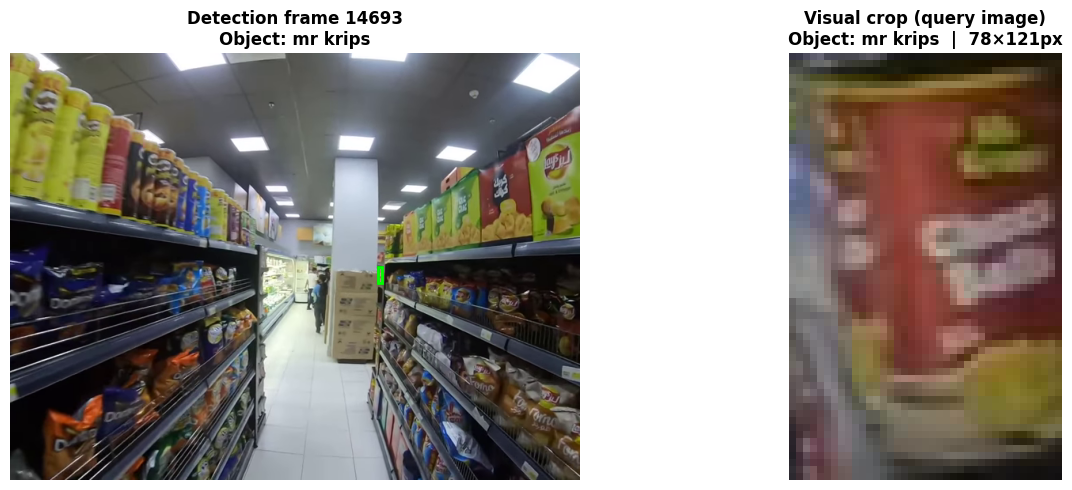


YOLO label: 0 0.649500 0.519556 0.007778 0.038333
(class cx cy w h — all values should be in [0, 1])


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# ── Download test clip and extract a few frames ────────────────────────────
print(f"Downloading {TEST_VIDEO}.mp4 ...")
clip_path = download_clip(bucket, TEST_VIDEO, TMP_DIR)

# Extract the first detection frame and its visual crop

frames = extract_frames(clip_path, needed_frames)
det_frame = frames[det_sample["video_frame_no"]]
vc_frame  = frames[vc_sample["video_frame_no"]]
needed_frames = {det_sample["video_frame_no"], vc_sample["video_frame_no"]}
print(f"Extracted {len(frames)} frames successfully")

# ── Visualize detection frame with bounding box ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Detection frame
det_rgb   = cv2.cvtColor(det_frame, cv2.COLOR_BGR2RGB)
axes[0].imshow(det_rgb)

actual_h, actual_w = det_frame.shape[:2]
scale_x = actual_w / det_sample["orig_w"]
scale_y = actual_h / det_sample["orig_h"]

rect = patches.Rectangle(
    (det_sample["x"] * scale_x, det_sample["y"] * scale_y),
    det_sample["w"] * scale_x, det_sample["h"] * scale_y,
    linewidth=2, edgecolor="lime", facecolor="none"
)

axes[0].add_patch(rect)
axes[0].set_title(
    f"Detection frame {det_sample['video_frame_no']}\n"
    f"Object: {det_sample['object_title']}",
    fontweight="bold"
)
axes[0].axis("off")

# Visual crop
cropped = crop_image(
    vc_frame,
    vc_sample["x"], vc_sample["y"],
    vc_sample["w"], vc_sample["h"],
    vc_sample["orig_w"], vc_sample["orig_h"]   # ← add these
)


axes[1].imshow(cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB))
axes[1].set_title(
    f"Visual crop (query image)\n"
    f"Object: {vc_sample['object_title']}  |  "
    f"{int(vc_sample['w'])}×{int(vc_sample['h'])}px",
    fontweight="bold"
)
axes[1].axis("off")

plt.tight_layout()
plt.show()

# ── Verify YOLO label ─────────────────────────────────────────────────────
label = make_yolo_label(
    det_sample["x"], det_sample["y"],
    det_sample["w"], det_sample["h"],
    det_sample["orig_w"], det_sample["orig_h"],
    actual_w, actual_h                          # ← add these
)
print(f"\nYOLO label: {label}")
print("(class cx cy w h — all values should be in [0, 1])")

In [ ]:
print(f"Actual frame shape (H, W, C) : {det_frame.shape}")
print(f"Annotation orig_w × orig_h   : {det_sample['orig_w']} × {det_sample['orig_h']}")
print(f"vc_frame shape               : {vc_frame.shape}")
print(f"Crop coords: x={vc_sample['x']:.1f}, y={vc_sample['y']:.1f}, "
      f"w={vc_sample['w']:.1f}, h={vc_sample['h']:.1f}")

Actual frame shape (H, W, C) : (540, 720, 3)
Annotation orig_w × orig_h   : 1440 × 1080
vc_frame shape               : (540, 720, 3)
Crop coords: x=742.1, y=587.2, w=78.3, h=121.7


## 5 · Full Extraction Loop

Processes one clip at a time:  
`download → extract all frames → write labels → upload to GCS → delete local → checkpoint`

Safe to restart — completed clips are skipped via checkpoint file.

In [ ]:
# ── Run the full extraction ────────────────────────────────────────────────
completed     = load_checkpoint()
remaining     = [vid for vid in workplan if vid not in completed]
manifest_rows = []
errors        = {}

print(f"Total videos    : {len(workplan):,}")
print(f"Already done    : {len(completed):,}")
print(f"Remaining       : {len(remaining):,}")

for video_uid in tqdm(remaining, desc="Extracting videos"):
    info = workplan[video_uid]
    try:
        counts = process_video(video_uid, info, bucket, TMP_DIR)
        completed.add(video_uid)
        manifest_rows.append({
            "video_uid"        : video_uid,
            "split"            : info["split"],
            "n_clips"          : len(info["clips"]),
            "detection_frames" : counts["detection"],
            "yolo_labels"      : counts["labels"],
            "visual_crops"     : counts["visual_crops"],
            "status"           : "ok",
        })
        if len(completed) % 50 == 0:
            save_checkpoint(completed)

    except Exception as e:
        errors[video_uid] = str(e)
        manifest_rows.append({
            "video_uid" : video_uid,
            "split"     : info["split"],
            "status"    : f"error: {e}",
        })

save_checkpoint(completed)
print(f"\nDone. {len(completed):,} videos completed, {len(errors):,} errors.")
if errors:
    print("Failed videos:", list(errors.keys())[:10])

## 6 · Save Extraction Manifest to GCS

In [ ]:
manifest_df = pd.DataFrame(manifest_rows)
manifest_df.to_parquet("/tmp/extraction_manifest.parquet", index=False)

blob = bucket.blob(GCS_OUT["manifest"])
blob.upload_from_filename("/tmp/extraction_manifest.parquet")

print("Extraction manifest saved to GCS.")
print(f"  gs://{BUCKET_NAME}/{GCS_OUT['manifest']}")
print()

ok = manifest_df[manifest_df.status == "ok"]
print("── Extraction Summary ──────────────────────────────────")
print(f"  Videos processed   : {len(ok):,}")
print(f"  Total clips        : {ok['n_clips'].sum():,}")
print(f"  Detection frames   : {ok['detection_frames'].sum():,}")
print(f"  YOLO labels        : {ok['yolo_labels'].sum():,}")
print(f"  Visual crops       : {ok['visual_crops'].sum():,}")
print(f"  Errors             : {len(errors):,}")
print("────────────────────────────────────────────────────────")

## 7 · Sanity Check — Verify GCS Output Structure

In [ ]:
# Spot check one video on GCS
CHECK_VIDEO = TEST_VIDEO
CHECK_SPLIT = workplan[CHECK_VIDEO]["split"]

# Use first clip_uid from this video for GCS path check
CHECK_CLIP = list(workplan[CHECK_VIDEO]["clips"].keys())[0]

prefixes = {
    "detection frames" : f"{GCS_OUT['detection_frames']}/{CHECK_SPLIT}/{CHECK_CLIP}/",
    "yolo labels"      : f"{GCS_OUT['yolo_labels']}/{CHECK_SPLIT}/{CHECK_CLIP}/",
    "visual crops"     : f"{GCS_OUT['visual_crops']}/{CHECK_SPLIT}/{CHECK_CLIP}/",
}

print(f"GCS output check for video : {CHECK_VIDEO}")
print(f"Checking clip              : {CHECK_CLIP}\n")
for label, prefix in prefixes.items():
    blobs = list(gcs_client.list_blobs(BUCKET_NAME, prefix=prefix, max_results=5))
    print(f"  {label:20s}: {len(blobs)} files found")
    for b in blobs[:2]:
        print(f"    gs://{BUCKET_NAME}/{b.name}")

print("\n── Final GCS structure ─────────────────────────────────")
print(f"gs://{BUCKET_NAME}/")
print(f"  ego4d/v2/annotations/      ← raw JSON (unchanged)")
print(f"  ego4d/v2/video_540ss/      ← source videos (unchanged)")
print(f"  processed/                 ← vq_query_sets.parquet + manifest")
print(f"  frames/detection/          ← {ok['detection_frames'].sum():,} frames")
print(f"  labels/yolo/               ← {ok['yolo_labels'].sum():,} label files")
print(f"  frames/retrieval/visual_crops/ ← {ok['visual_crops'].sum():,} query images")
print("────────────────────────────────────────────────────────")

---
### Next: `03_detection_baseline.ipynb`
Inputs from this notebook:
- `gs://egorecall-data/frames/detection/{split}/{clip_uid}/*.jpg`
- `gs://egorecall-data/labels/yolo/{split}/{clip_uid}/*.txt`
- `gs://egorecall-data/processed/extraction_manifest.parquet`

In [ ]:
# # # ── Export to VM — run once in Colab, then comment out ───────────────────
# !jupyter nbconvert --to script 02_frame_extraction.ipynb
# !gsutil cp 02_frame_extraction.py gs://egorecall-data/processed/02_frame_extraction.py
# print("Uploaded to GCS. Comment this cell out before re-running.")